In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy.optimize

import os

In [2]:
window =  11

In [3]:
### calculate moving average
# define function for use of numpy arrays
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w


### plotting routine
def plot_range(SampleData,ax1,col='steelblue',prctl=[5,25,50,75,95]):
 
 SDist=np.percentile(SampleData,prctl,axis=1).T

 x=np.arange(0,len(pd.DatetimeIndex(SampleData.time).year))
 #ax1.plot(x, SDist[:,2],)
 for i in range(int(np.floor(len(prctl)/2))+1):
     alph=0.15+(i/len(prctl))
     ax1.fill_between(x,SDist[:,0+i], SDist[:,len(prctl)-1-i], color=col, alpha=alph, edgecolor="none")
 return SDist

### plotting routine
def plot_bxp(SampleData,tim,j,ax1,col='steelblue',prctl=[5,25,50,75,95],linestyle='-',alpha=0.2,lbl=''):
    SDist=np.percentile(SampleData,prctl,axis=1).T
    for i in range(int(np.floor(len(prctl)/2))+1):
        ax1.vlines(tim,SDist[j,0+i], SDist[j,len(prctl)-1-i], color=col,linestyle=linestyle)
    
    ax1.plot(tim,SDist[j,int(np.floor(len(prctl)/2))], color=col, marker='o',label=lbl)

# Emission data

In [4]:
e_flat10=pd.read_csv('flat10.csv',header=4)
e_flat10_cdr=pd.read_csv('flat10_cdr.csv',header=4)
e_flat10_zec=pd.read_csv('flat10_zec.csv',header=4)
e_flat10_nz=pd.read_csv('flat10_cdr.csv',header=4)
e_flat10_nz[150:]=0


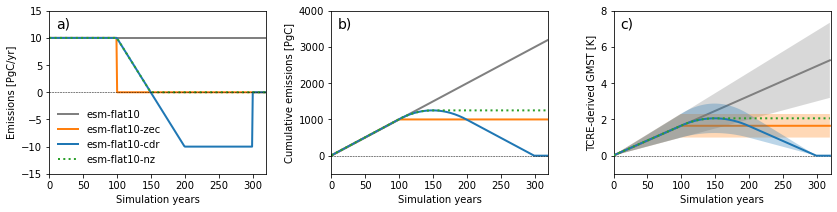

In [5]:
fig = plt.figure(figsize=(14,3))

# subfigure 1
sub = fig.add_subplot(1, 3, 1)

sub.set_ylabel("Emissions [PgC/yr]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-15,15)
sub.plot(np.repeat(10,320), color='gray', lw=2, label="esm-flat10")
sub.plot(np.array(e_flat10_zec)[:,1], color="tab:orange", lw=2, label="esm-flat10-zec")
sub.plot(np.array(e_flat10_cdr)[:,1], color="tab:blue", lw=2, label="esm-flat10-cdr")
sub.plot(np.array(e_flat10_nz)[:,1], color="tab:green", lw=2, label="esm-flat10-nz", linestyle=":")

sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.legend(frameon=False, loc="lower left")
sub.annotate('a)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 2
sub = fig.add_subplot(1, 3, 2)

sub.set_ylabel("Cumulative emissions [PgC]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-500,4000)
sub.plot(np.arange(0,320)*10, color='grey', lw=2, zorder=2)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1]), lw=2, color='tab:orange')
sub.plot(np.cumsum(np.array(e_flat10_cdr)[:,1]), lw=2, color="tab:blue")
sub.plot(np.cumsum(np.array(e_flat10_nz)[:,1]), lw=2, color="tab:green", linestyle=":")
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('b)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 3
# TCRE values/range from AR6 - 5.5.1.4
sub = fig.add_subplot(1, 3, 3)

sub.set_ylabel("TCRE-derived GMST [K]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-1,8)
sub.plot(np.arange(0,320)*10*1.65/1000, color='grey', lw=2, zorder=1)
sub.fill_between(np.arange(0,320), np.arange(0,320)*10*1.0/1000, np.arange(0,320)*10*2.3/1000, color="gray", alpha=0.3, edgecolor="none", zorder=1)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1])*1.65/1000, lw=2, color='tab:orange', zorder=2)
sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_zec)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_zec)[:,1])*2.3/1000, lw=2, color="tab:orange", alpha=0.3, edgecolor="none", zorder=2)
sub.plot(np.cumsum(np.array(e_flat10_cdr)[:,1])*1.65/1000, lw=2, color="tab:blue", zorder=3)
sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_cdr)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_cdr)[:,1])*2.3/1000, lw=2, color="tab:blue", alpha=0.3, edgecolor="none", zorder=3)
sub.plot(np.cumsum(np.array(e_flat10_nz)[:,1])*1.65/1000, lw=2, color="tab:green", linestyle=":", zorder=4)
#sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_nz)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_nz)[:,1])*2.3/1000, lw=2, color="tab:green", alpha=0.1, edgecolor="none", zorder=4)
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('c)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

fig.subplots_adjust(wspace=0.3, hspace=0)

plt.savefig("images/flat10_exp_design.pdf", bbox_inches='tight')
plt.savefig("images/flat10_exp_design.jpg", bbox_inches='tight')


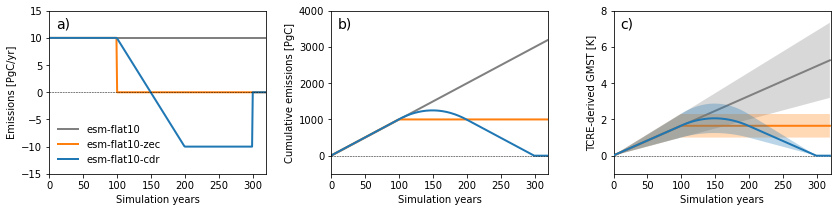

In [6]:
fig = plt.figure(figsize=(14,3))

# subfigure 1
sub = fig.add_subplot(1, 3, 1)

sub.set_ylabel("Emissions [PgC/yr]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-15,15)
sub.plot(np.repeat(10,320), color='gray', lw=2, label="esm-flat10")
sub.plot(np.array(e_flat10_zec)[:,1], color="tab:orange", lw=2, label="esm-flat10-zec")
sub.plot(np.array(e_flat10_cdr)[:,1], color="tab:blue", lw=2, label="esm-flat10-cdr")

sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.legend(frameon=False, loc="lower left")
sub.annotate('a)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 2
sub = fig.add_subplot(1, 3, 2)

sub.set_ylabel("Cumulative emissions [PgC]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-500,4000)
sub.plot(np.arange(0,320)*10, color='grey', lw=2, zorder=2)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1]), lw=2, color='tab:orange')
sub.plot(np.cumsum(np.array(e_flat10_cdr)[:,1]), lw=2, color="tab:blue")
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('b)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 3
# TCRE values/range from AR6 - 5.5.1.4
sub = fig.add_subplot(1, 3, 3)

sub.set_ylabel("TCRE-derived GMST [K]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-1,8)
sub.plot(np.arange(0,320)*10*1.65/1000, color='grey', lw=2, zorder=1)
sub.fill_between(np.arange(0,320), np.arange(0,320)*10*1.0/1000, np.arange(0,320)*10*2.3/1000, color="gray", alpha=0.3, edgecolor="none", zorder=1)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1])*1.65/1000, lw=2, color='tab:orange', zorder=2)
sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_zec)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_zec)[:,1])*2.3/1000, lw=2, color="tab:orange", alpha=0.3, edgecolor="none", zorder=2)
sub.plot(np.cumsum(np.array(e_flat10_cdr)[:,1])*1.65/1000, lw=2, color="tab:blue", zorder=3)
sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_cdr)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_cdr)[:,1])*2.3/1000, lw=2, color="tab:blue", alpha=0.3, edgecolor="none", zorder=3)
#sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_nz)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_nz)[:,1])*2.3/1000, lw=2, color="tab:green", alpha=0.1, edgecolor="none", zorder=4)
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('c)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

fig.subplots_adjust(wspace=0.3, hspace=0)

plt.savefig("images/flat10_exp_design_3exps.pdf", bbox_inches='tight')
plt.savefig("images/flat10_exp_design_3exps.png", bbox_inches='tight', dpi=300)


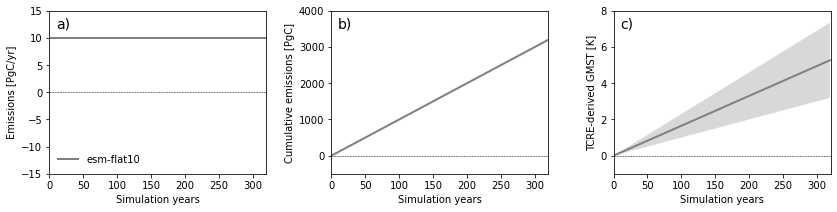

In [7]:
fig = plt.figure(figsize=(14,3))

# subfigure 1
sub = fig.add_subplot(1, 3, 1)

sub.set_ylabel("Emissions [PgC/yr]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-15,15)
sub.plot(np.repeat(10,320), color='gray', lw=2, label="esm-flat10")

sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.legend(frameon=False, loc="lower left")
sub.annotate('a)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 2
sub = fig.add_subplot(1, 3, 2)

sub.set_ylabel("Cumulative emissions [PgC]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-500,4000)
sub.plot(np.arange(0,320)*10, color='grey', lw=2, zorder=2)
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('b)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 3
# TCRE values/range from AR6 - 5.5.1.4
sub = fig.add_subplot(1, 3, 3)

sub.set_ylabel("TCRE-derived GMST [K]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-1,8)
sub.plot(np.arange(0,320)*10*1.65/1000, color='grey', lw=2, zorder=1)
sub.fill_between(np.arange(0,320), np.arange(0,320)*10*1.0/1000, np.arange(0,320)*10*2.3/1000, color="gray", alpha=0.3, edgecolor="none", zorder=1)
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('c)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

fig.subplots_adjust(wspace=0.3, hspace=0)

plt.savefig("images/flat10_exp_design_1exp.pdf", bbox_inches='tight')
plt.savefig("images/flat10_exp_design_1exp.png", bbox_inches='tight', dpi=300)


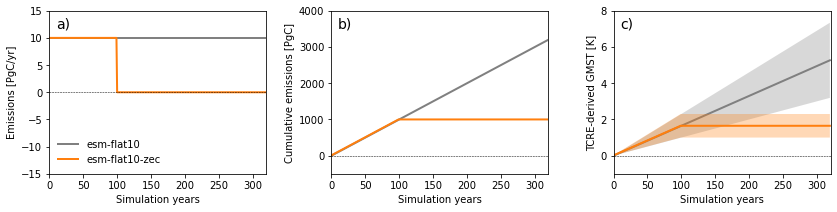

In [8]:
fig = plt.figure(figsize=(14,3))

# subfigure 1
sub = fig.add_subplot(1, 3, 1)

sub.set_ylabel("Emissions [PgC/yr]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-15,15)
sub.plot(np.repeat(10,320), color='gray', lw=2, label="esm-flat10")
sub.plot(np.array(e_flat10_zec)[:,1], color="tab:orange", lw=2, label="esm-flat10-zec")

sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.legend(frameon=False, loc="lower left")
sub.annotate('a)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 2
sub = fig.add_subplot(1, 3, 2)

sub.set_ylabel("Cumulative emissions [PgC]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-500,4000)
sub.plot(np.arange(0,320)*10, color='grey', lw=2, zorder=2)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1]), lw=2, color='tab:orange')
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('b)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 3
# TCRE values/range from AR6 - 5.5.1.4
sub = fig.add_subplot(1, 3, 3)

sub.set_ylabel("TCRE-derived GMST [K]")
sub.set_xlabel("Simulation years")
sub.set_xlim(0,320)
sub.set_ylim(-1,8)
sub.plot(np.arange(0,320)*10*1.65/1000, color='grey', lw=2, zorder=1)
sub.fill_between(np.arange(0,320), np.arange(0,320)*10*1.0/1000, np.arange(0,320)*10*2.3/1000, color="gray", alpha=0.3, edgecolor="none", zorder=1)
sub.plot(np.cumsum(np.array(e_flat10_zec)[:,1])*1.65/1000, lw=2, color='tab:orange', zorder=2)
sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_zec)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_zec)[:,1])*2.3/1000, lw=2, color="tab:orange", alpha=0.3, edgecolor="none", zorder=2)
#sub.fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_nz)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_nz)[:,1])*2.3/1000, lw=2, color="tab:green", alpha=0.1, edgecolor="none", zorder=4)
sub.axhline(0, color="black", lw=0.5, linestyle="--")
sub.annotate('c)', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, ha='left', va='center')

fig.subplots_adjust(wspace=0.3, hspace=0)

plt.savefig("images/flat10_exp_design_2exps.pdf", bbox_inches='tight')
plt.savefig("images/flat10_exp_design_2exps.png", bbox_inches='tight', dpi=300)


#Figure 2 (diagram)

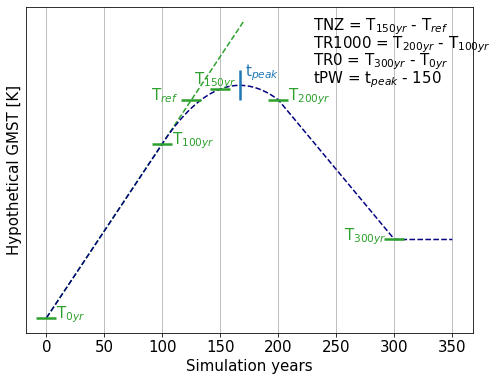

In [9]:
t = np.arange(350 * 12) / 12.
y = np.zeros(350 * 12) * 1.
y[0:1200] = 10.
y[1200:2400] = 10. - (0.15 *  np.arange(100*12)/12.)
y[2400:3601] = -8


yy = y.cumsum()/12.

#plt.plot(t,y)

t2 = np.arange(170 * 12) / 12.
y2 = np.ones(170 * 12) * 10.
y2y2 = y2.cumsum()/12.

pkw=np.argmax(yy)

width=2.5
symcolor='tab:green'
symcolor2 = 'tab:blue'
linecolor2 = 'tab:green'

fontsize=15

plt.rc('xtick', labelsize=fontsize) 

fig, ax = plt.subplots(figsize=(8,6))

ax.plot(t2,y2y2, color=linecolor2, linestyle='--')

ax.plot(t,yy, color='navy', linestyle='--')

ax.plot(0,0, '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{0yr}$', (0, 0), xytext=(10,0), textcoords='offset points', color=symcolor, fontsize=fontsize)

ax.plot(300,yy[-1], '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{300yr}$', (300,yy[-1] ), xytext=(-50,0), textcoords='offset points', color=symcolor, fontsize=fontsize)

ax.plot(pkw/12,yy[pkw], '|', color=symcolor2, markersize=30, markeredgewidth=width)
#ax.axvline(150,color=symcolor2,linestyle=':')
ax.annotate('t$_{peak}$', (pkw/12,yy[pkw]), xytext=(5,10), textcoords='offset points', color=symcolor2, fontsize=fontsize)

ax.plot(100,1000, '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{100yr}$', (100, 1000), xytext=(10,0), textcoords='offset points', color=symcolor, fontsize=fontsize)

ax.plot(200,yy[12*200], '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{200yr}$', (200, yy[12*200]), xytext=(10,0), textcoords='offset points', color=symcolor, fontsize=fontsize)

ax.plot(125,1250, '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{ref}$', (125, 1250), xytext=(-40,0), textcoords='offset points', color=symcolor, fontsize=fontsize)

ax.plot(150,yy[12*150], '_', color=symcolor, markersize=20, markeredgewidth=width)
ax.annotate('T$_{150yr}$', (140, yy[12*150]), xytext=(-15,5), textcoords='offset points', color=symcolor, fontsize=fontsize)

plt.ylabel('Hypothetical GMST [K]', fontsize=fontsize)
plt.xlabel('Simulation years', fontsize=fontsize)
plt.yticks([])

ax.text(230, 1650, r'TNZ = T$_{150yr}$ - T$_{ref}$', fontsize=fontsize)
ax.text(230, 1550, r'TR1000 = T$_{200yr}$ - T$_{100yr}$', fontsize=fontsize)
ax.text(230, 1450, r'TR0 = T$_{300yr}$ - T$_{0yr}$', fontsize=fontsize)
ax.text(230, 1350, r'tPW = t$_{peak}$ - 150', fontsize=fontsize)
plt.grid()
plt.savefig('images/metrics_schematic.png', dpi=300)

# SCM data

In [10]:
# import fair, magicc, CSCM

# FaIR
ds_fair = xr.open_dataset('SCM_data/timeseries/flat10_FaIR.nc')

# MAGICC
ds_magicc = xr.open_dataset('SCM_data/timeseries/flat10_magicc.nc')

ds_magicc=ds_magicc.rename_vars(name_dict={'Atmospheric_Concentrations__CO2':'co2_concentration'})
ds_magicc=ds_magicc.rename_vars(name_dict={'Surface_Air_Temperature_Change':'temperature'})
ds_magicc=ds_magicc.rename_dims(dims_dict={'ensemble_member':'config'})

ds_magicc["scenario"]=("scenario",['esm-flat10','esm-flat10_cdr','esm-flat10_zec'])

# CSCM
ds_cicero = xr.open_dataset('SCM_data/timeseries/cic_flat10.nc')

ds_cicero=ds_cicero.rename_vars(name_dict={'concentrations-CO2':'co2_concentration'})
ds_cicero=ds_cicero.rename_vars(name_dict={'dT_glob':'temperature'})

#ds_cicero["scenario"]=("scenario",['esm-flat10','esm-flat10_zec','esm-flat10_cdr','esm-piControl'])

In [11]:
ds_cicero['temperature']=ds_cicero['temperature'].transpose("time", "scenario", "config")
ds_cicero['co2_concentration']=ds_cicero['co2_concentration'].transpose("time", "scenario", "config")   
ds_cicero['OHC700']=ds_cicero['OHC700'].transpose("time", "scenario", "config")
ds_cicero['RIB_glob'].transpose("time", "scenario", "config")
ds_cicero=ds_cicero.where(ds_cicero.time>=1850, drop=True)
ds_cicero['tcre']=ds_cicero['tcre'].isel({'time':0})
ds_cicero['zec50']=ds_cicero['zec50'].isel({'time':0})
ds_cicero['zec100']=ds_cicero['zec100'].isel({'time':0})


# Load ESM Data

In [12]:
# ESM data
def extd(ts,leng):
    out=np.zeros(leng)
    if leng>len(ts):
        out[:len(ts)]=ts.values
        out[len(ts):]=ts.iloc[-1]
    else:
        out=ts[:leng]
    return out
#mdls=['ACCESS-ESM1-5','CESM2','GFDL-ESM4','GISS','NorESM2-LM','CNRM-ESM2-1','MPI-ESM1-2-LR']
mdls=['ACCESS-ESM1-5','CESM2','GFDL-ESM4','GISS','NorESM2-LM','MPI-ESM1-2-LR','CNRM-ESM2-1','UKESM','UVic-ESCM-2-10','HadCM3LC-Bris']
expt=['esm-pictrl','1pctco2','flat10','flat10-zec','flat10-cdr']
flds=['tas','co2','fgco2','nbp','fCmissing']

ed={}
for m in mdls:
    ed[m]={}
    for e in expt:
        tmpa=[]
        for f in flds:
                print(f)
                fl10='ESM_data/'+m+'/'+'flat10'+'_'+f+'_'+m+'.nc'
                fl='ESM_data/'+m+'/'+e+'_'+f+'_'+m+'.nc'
                if os.path.exists(fl) and os.path.exists(fl10):
                    otmp=xr.open_dataset(fl)
                    otmp10=xr.open_dataset(fl10)
                    if 'nep' in list(otmp.keys()):
                        otmp=otmp.rename_vars({"nep": "nbp"})
                    if 'nep' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"nep": "nbp"})
                    if 'CO2_GLOB' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"CO2_GLOB": "co2"})
                        otmp=otmp.rename_vars({"CO2_GLOB": "co2"})
                    if 'NBP_GLOB' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"NBP_GLOB": "nbp"})
                        otmp=otmp.rename_vars({"NBP_GLOB": "nbp"})
                    if 'FGCO2_GLOB' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"FGCO2_GLOB": "fgco2"})
                        otmp=otmp.rename_vars({"FGCO2_GLOB": "fgco2"})    
                    if 'TIME' in list(otmp10.coords.keys()):                  
                        otmp10=otmp10.swap_dims({"TIME": "time"}).rename_vars({"TIME": "time"})
                    if 't' in list(otmp10.coords.keys()):                  
                        otmp10=otmp10.swap_dims({"t": "time"}).rename_vars({"t": "time"})
                    if 't' in list(otmp.coords.keys()):                  
                        otmp=otmp.swap_dims({"t": "time"}).rename_vars({"t": "time"})
                    if 'TIME' in list(otmp.coords.keys()):                  
                        otmp=otmp.swap_dims({"TIME": "time"}).rename_vars({"TIME": "time"})
                    if 'TAS_GLOB' in list(otmp10.keys()):                  
                        otmp10=otmp10.rename_vars({"TAS_GLOB": "tas"})
                    if 'TAS_GLOB' in list(otmp.keys()):                  
                        otmp=otmp.rename_vars({"TAS_GLOB": "tas"})
                        
                    if 'temp_mm_1_5m' in list(otmp10.keys()):                  
                        otmp10=otmp10.rename_vars({"temp_mm_1_5m": "tas"})
                    if 'temp_mm_1_5m' in list(otmp.keys()):                  
                        otmp=otmp.rename_vars({"temp_mm_1_5m": "tas"})
                    
                    if 'field1564_mm_hyb' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"field1564_mm_hyb": "co2"})
                        otmp=otmp.rename_vars({"field1564_mm_hyb": "co2"})
                    if 'unknown' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"unknown": "nbp"})
                        otmp=otmp.rename_vars({"unknown": "nbp"})
                   
                    if 'field1560_mm_srf' in list(otmp10.keys()):
                        otmp10=otmp10.rename_vars({"field1560_mm_srf": "fgco2"})
                        otmp=otmp.rename_vars({"field1560_mm_srf": "fgco2"})
                    if 'FCMISSING' in list(otmp.keys()):                  
                        otmp=otmp.rename_vars({"FCMISSING": "fCmissing"})    
                    if 'FCMISSING' in list(otmp10.keys()):                  
                        otmp10=otmp10.rename_vars({"FCMISSING": "fCmissing"})      
                    if '__xarray_dataarray_variable__' in list(otmp10.keys()):                  
                        otmp10=otmp10.rename_vars({"__xarray_dataarray_variable__": f})
                    if '__xarray_dataarray_variable__' in list(otmp.keys()):                  
                        otmp=otmp.rename_vars({"__xarray_dataarray_variable__": f})

                    tmp=otmp.copy(deep=True)
                    tmp10=otmp10.copy(deep=True)
                    
                    if e=='flat10':
                        if len(tmp.time)<1000:
                            tmp.coords['time']=pd.date_range('1700-01-01', periods=tmp['time'].values.shape[0],freq='Y')
                        else:
                            tmp.coords['time']=pd.date_range('1700-01-01', periods=tmp['time'].values.shape[0],freq='M')
                        tmp=tmp[f]    
                    else: 
                        if len(tmp.time)<1000:
                            tmp10.coords['time']=pd.date_range('1700-01-01', periods=tmp10['time'].values.shape[0],freq='Y')
                            tmp.coords['time']=pd.date_range('1800-01-01', periods=tmp['time'].values.shape[0],freq='Y')
                        else:
                            tmp10.coords['time']=pd.date_range('1700-01-01', periods=tmp10['time'].values.shape[0],freq='M')
                            tmp.coords['time']=pd.date_range('1800-01-01', periods=tmp['time'].values.shape[0],freq='M')
  
                        tmp=xr.concat((tmp10.where(tmp10['time.year'] < 1800, drop=True)[f],tmp[f]),'time')
                    tmp=tmp.groupby('time.year').mean()
                    if len(tmp.shape)==2:
                        tmp=tmp.sel(lat=0).sel(lon=0).drop('lev')
                    if len(tmp.shape)==3:
                        tmp=tmp.sel(lat=0).sel(lon=0).drop('lat').drop('lon')
                    if len(tmp.shape)==4:
                        if 'lev' in list(otmp10.coords.keys()):
                            tmp=tmp.sel(lat=0).sel(lon=0).isel(lev=[0]).drop('lat').drop('lon').drop('lev')
                        else:
                            tmp=tmp.sel(lat=0).sel(lon=0).isel(plev=[0]).drop('lat').drop('lon').drop('plev')
                    
                    if tmp.name=='tas':            
                        t10=tmp[0:20].mean().values
                        d10=tmp[20:40].mean().values-t10
                        t0=t10-d10/2
                        tmp=tmp-t0
                    tmpa.append(tmp)
                    if f=='fgco2' and m=='NorESM2-LM' and e=='flat10':
                     0
                else:
                    print(m+e+f)
                
             
        ed[m][e]=xr.merge(tmpa)
        if len(tmpa)>0:
            ed[m][e]['fco2fos']=ed[m][e]['tas'].copy()
            if e=='flat10':
                    ed[m][e]['fco2fos'].values=extd(e_flat10['Emission Rate (PgC a-1)'],len(ed[m][e]['year']))
            if e=='flat10-cdr':
                    ed[m][e]['fco2fos'].values=extd(e_flat10_cdr['Emission Rate (PgC a-1)'],len(ed[m][e]['year']))
            if e=='flat10-zec':
                    ed[m][e]['fco2fos'].values=extd(e_flat10_zec['Emission Rate (PgC a-1)'],len(ed[m][e]['year']))
            if m=='ACCESS-ESM1-5':
                ed[m][e]['co2']=ed[m][e]['co2']*1e6

            if m=='GFDL-ESM4':
                ed[m][e]['co2']=ed[m][e]['co2'].isel(lev=0)*1e6
                ed[m][e]['nbp']=ed[m][e]['nbp']*5.1e14/1e12*3600*24*365
                aco2=np.diff(ed[m][e]['co2'][:],append=ed[m][e]['co2'][-1])*2.12
                ln=len(ed[m][e]['fco2fos'])
                ed[m][e]['fgco2']=ed[m][e]['fgco2'][:ln]
                

            if m=='CESM2':
                ed[m][e]['fgco2']=ed[m][e]['fgco2']/1e15
                ed[m][e]['nbp']=ed[m][e]['nbp']/1e15
                
                ed[m][e]['co2']=280+np.cumsum(ed[m][e]['fco2fos']-ed[m][e]['fgco2']-ed[m][e]['nbp'])/2.12
            
                ed[m][e]['co2']=280+np.cumsum(ed[m][e]['fco2fos']-ed[m][e]['fgco2']-ed[m][e]['nbp'])/2.12
            if m=='NorESM2-LM':
                ed[m][e]['co2']=ed[m][e]['co2']*1e6
                #ed[m][e]['nbp']=ed[m][e]['nbp']*5.1e14/1e12*3600*24*365
                aco2=np.diff(ed[m][e]['co2'][:],append=ed[m][e]['co2'][-1])*2.12
                #ed[m][e]['nbp']=ed[m][e]['fco2fos']-aco2-ed[m][e]['fgco2']
                #ed[m][e]['fgco2']=ed[m][e]['fgco2']*5.1e14/1e12*3600*24*365
            if m=='UKESM':
                ed[m][e]['nbp']=ed[m][e]['nbp']*5.1e14/1e12*.29
                #ed[m][e]['nbp']=ed[m][e]['nbp']*5.1e14/1e12*3600*24*365
                #ed[m][e]['fgco2']=ed[m][e]['fgco2']*5.1e14/1e12*3600*24*365*.71
            if m=='CNRM-ESM2-1':
                ed[m][e]['fgco2']=ed[m][e]['fgco2']-ed[m][e]['fCmissing']
                #ed[m][e]['nbp']=ed[m][e]['nbp']*5.1e14/1e12*3600*24*365
                #ed[m][e]['fgco2']=ed[m][e]['fgco2']*5.1e14/1e12*3600*24*365*.71
            if m=='HadCM3LC-Bris':
                0#ed[m][e]['fgco2']=ed[m][e]['fgco2']*5.1e14/1e12*.71
                ed[m][e]['nbp']=ed[m][e]['nbp']*.29
                


ed["GFDL-ESM4"]['flat10']['fgco2'][0] = ed["GFDL-ESM4"]['flat10']['fgco2'][0]-10        # correct first ocean value of GFDL-ESM4
ed["GFDL-ESM4"]['flat10-zec']['fgco2'][0] = ed["GFDL-ESM4"]['flat10-zec']['fgco2'][0]-10        # correct first ocean value of GFDL-ESM4
ed["GFDL-ESM4"]['flat10-cdr']['fgco2'][0] = ed["GFDL-ESM4"]['flat10-cdr']['fgco2'][0]-10        # correct first ocean value of GFDL-ESM4

for i,m in enumerate(mdls):
    print(m)
    try:
        ed[m]['flat10-cdr']['C_atm']=(ed[m]['flat10-cdr']['co2']-ed[m]['flat10']['co2'][0])*2.13
    except:
        print('fail cdr')
    try:
        ed[m]['flat10-zec']['C_atm']=(ed[m]['flat10-zec']['co2']-ed[m]['flat10']['co2'][0])*2.13
    except:
        print('fail zec')
    try:
        ed[m]['flat10']['C_atm']=(ed[m]['flat10']['co2']-ed[m]['flat10']['co2'][0])*2.13

    except:
        print('fail flat')    


t0mat={}
for i,m in enumerate(mdls):
    x = np.arange(0,50)
    y = np.array(ed[m]['flat10']['tas'][:50])
    t0mat[m]=y[1]
    ed[m]['flat10-cdr']['tas'] = ed[m]['flat10-cdr']['tas']-y[1]
    ed[m]['flat10-zec']['tas'] = ed[m]['flat10-zec']['tas']-y[1]
    ed[m]['flat10']['tas'] = ed[m]['flat10']['tas']-y[1]

tas
ACCESS-ESM1-5esm-pictrltas
co2
ACCESS-ESM1-5esm-pictrlco2
fgco2
ACCESS-ESM1-5esm-pictrlfgco2
nbp
ACCESS-ESM1-5esm-pictrlnbp
fCmissing
ACCESS-ESM1-5esm-pictrlfCmissing
tas
ACCESS-ESM1-51pctco2tas
co2
ACCESS-ESM1-51pctco2co2
fgco2
ACCESS-ESM1-51pctco2fgco2
nbp
ACCESS-ESM1-51pctco2nbp
fCmissing
ACCESS-ESM1-51pctco2fCmissing
tas
co2


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557:

fgco2
nbp


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557:

fCmissing
ACCESS-ESM1-5flat10fCmissing
tas
co2


...

nbp
fCmissing
MPI-ESM1-2-LRflat10-zecfCmissing
tas


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode tim

co2
fgco2


/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/core/indexing.py:557: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  array = array.get_duck_array()
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/Users/CDKoven/miniforge3/lib/python3.9/site-packages/xarray/coding/times.py:724: 

nbp
fCmissing
MPI-ESM1-2-LRflat10-cdrfCmissing
tas
CNRM-ESM2-1esm-pictrltas
co2
CNRM-ESM2-1esm-pictrlco2
fgco2
CNRM-ESM2-1esm-pictrlfgco2
nbp
CNRM-ESM2-1esm-pictrlnbp
fCmissing
CNRM-ESM2-1esm-pictrlfCmissing
tas
CNRM-ESM2-11pctco2tas
co2
CNRM-ESM2-11pctco2co2
fgco2
CNRM-ESM2-11pctco2fgco2
nbp
CNRM-ESM2-11pctco2nbp
fCmissing
CNRM-ESM2-11pctco2fCmissing
tas
co2
fgco2
nbp
fCmissing
tas
co2
fgco2
nbp
fCmissing
tas
co2
fgco2
nbp
fCmissing
tas
UKESMesm-pictrltas
co2
UKESMesm-pictrlco2
fgco2
UKESMesm-pictrlfgco2
nbp
UKESMesm-pictrlnbp
fCmissing
UKESMesm-pictrlfCmissing
tas
UKESM1pctco2tas
co2
UKESM1pctco2co2
fgco2
UKESM1pctco2fgco2
nbp
UKESM1pctco2nbp
fCmissing
UKESM1pctco2fCmissing
tas
co2
fgco2
nbp
fCmissing
UKESMflat10fCmissing
tas
co2
fgco2
nbp
fCmissing
UKESMflat10-zecfCmissing
tas
co2
fgco2
nbp
fCmissing
UKESMflat10-cdrfCmissing
tas
UVic-ESCM-2-10esm-pictrltas
co2
UVic-ESCM-2-10esm-pictrlco2
fgco2
UVic-ESCM-2-10esm-pictrlfgco2
nbp
UVic-ESCM-2-10esm-pictrlnbp
fCmissing
UVic-ESCM-2-10esm-

In [13]:
ed[m][e]['C_atm']

<xarray.DataArray 'C_atm' (year: 321)>
array([   0.        ,    8.70474961,   16.57694204,   24.49983292,
         32.14170965,   38.82027733,   45.26584163,   51.91730992,
         58.18932118,   64.03241804,   70.07722036,   76.36998569,
         82.15573819,   88.20485363,   94.40269249,   99.97267195,
        105.81905529,  111.62784991,  117.57273799,  123.50207658,
        128.72432796,  134.19499522,  140.13941346,  145.94859989,
        151.9275691 ,  157.23897929,  162.8995456 ,  168.46027938,
        174.00049771,  179.16892944,  184.51329187,  190.16559741,
        195.61589136,  201.26257273,  206.4991474 ,  210.96493622,
        215.95498756,  221.31194555,  226.09385762,  231.38611625,
        236.84873147,  242.48643938,  247.61238214,  252.71110448,
        257.65792194,  262.82654097,  267.91613885,  273.24317239,
        278.77132313,  284.5707219 ,  290.63182276,  296.06812806,
        300.73791947,  305.64387306,  311.0079358 ,  316.13456442,
        321.92553562,  327.0892175 ,  332.25575604,  337.84278769,
        343.3042583 ,  348.45552256,  353.51587054,  358.54619233,
        364.0672397 ,  369.12552206,  373.71098617,  378.56186987,
        383.34170776,  388.95672763,  394.67750731,  400.25601754,
        405.71228561,  410.96781306,  416.55527775,  422.03248086,
        427.34117677,  432.67642842,  437.93941624,  443.39727142,
...
        100.36355608,   95.10885492,   90.31278163,   85.53273364,
         80.35421871,   75.70586624,   70.77486157,   65.36486992,
         60.30360926,   55.24822401,   50.7573187 ,   46.05582452,
         40.82525865,   36.06772259,   31.5391228 ,   26.68942878,
         21.28116685,   16.37577568,   11.87231361,    7.72676444,
          3.33888239,   -1.41936115,   -6.2345226 ,  -11.02037017,
        -15.23863272,  -19.04436205,  -23.00505605,  -27.69945319,
        -31.97682195,  -36.08191104,  -40.11629363,  -43.92937363,
        -48.1429975 ,  -51.90879757,  -56.27546996,  -60.06170352,
        -63.36048831,  -67.13225147,  -70.86830929,  -74.87576197,
        -78.85960092,  -82.27273588,  -85.87952458,  -89.63274112,
        -93.67060965,  -97.20021186, -100.85566476, -104.80310906,
       -108.45705953, -112.35443382, -115.7348229 , -119.21409872,
       -122.75112545, -125.83871778, -129.47397994, -132.78298203,
       -135.96963005, -138.88331602, -142.19507544, -145.52700061,
       -148.74640487, -152.16936691, -155.20406713, -158.35687636,
       -160.99729591, -164.10776732, -167.12444563, -170.35447188,
       -173.50340863, -176.46674462, -179.50268241, -182.49154347,
       -185.30006334, -188.06277897, -191.07297291, -194.28538532,
       -196.03266934])
Coordinates:
  * year            (year) int64 1700 1701 1702 1703 ... 2017 2018 2019 2020
    ht              float32 -1.0
    latitude        float32 0.0
    longitude       float32 178.1
    hybrid_p_x1000  float32 997.0
    surface         float32 0.0

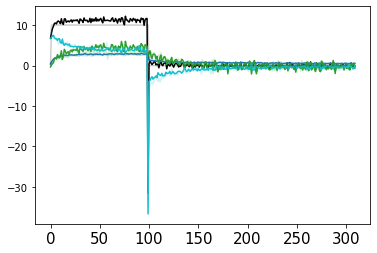

In [14]:
m='NorESM2-LM'
e='flat10-zec'
plt.plot(ed[m][e]['nbp']+ed[m][e]['fgco2']+np.diff(ed[m][e]['C_atm'],append=ed[m][e]['C_atm'][-1]),color='k')
plt.plot(ed[m][e]['fgco2'],color='tab:blue')
plt.plot(ed[m][e]['nbp'],color='tab:green')
plt.plot(np.diff(ed[m][e]['C_atm'],append=ed[m][e]['C_atm'][-1]),color='tab:cyan')
plt.grid()
m='CESM2'

plt.plot(ed[m][e]['nbp']+ed[m][e]['fgco2']+np.diff(ed[m][e]['C_atm'],prepend=ed[m][e]['C_atm'][0]),color='k',alpha=.2)
plt.plot(ed[m][e]['fgco2'],color='tab:blue',alpha=.2)
plt.plot(ed[m][e]['nbp'],color='tab:green',alpha=.2)
plt.plot(np.diff(ed[m][e]['C_atm'],append=ed[m][e]['C_atm'][-1]),color='tab:cyan',alpha=.2)
plt.grid()

In [15]:
colors=["tab:cyan","tab:olive","tab:green","tab:red","tab:gray","tab:pink","limegreen","tab:brown", "slateblue","gold"]


Figure 4 (ESM/SCM)

ACCESS-ESM1-5
CESM2
GFDL-ESM4
GISS
NorESM2-LM
MPI-ESM1-2-LR
CNRM-ESM2-1
UKESM
UVic-ESCM-2-10
HadCM3LC-Bris


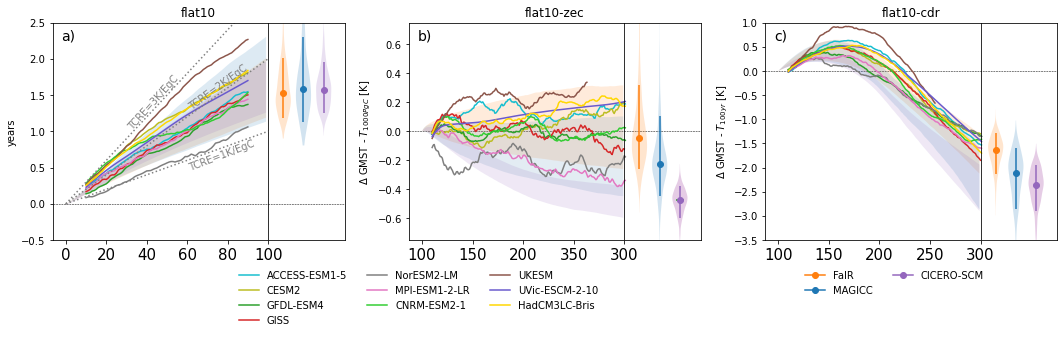

In [16]:
# combined SCM and ESM results
mcols=colors
#mcols=["tab:blue","tab:orange","tab:green","tab:red","tab:gray","tab:purple","tab:cyan","tab:brown"]
t_100=ds_fair.temperature.sel(scenario='esm-flat10_zec').isel(time=100)
t_100pl=ds_fair.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))
t_100plc=ds_fair.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,200))

m_100=ds_magicc.temperature.sel(scenario='esm-flat10_zec').isel(time=100).T
m_100pl=ds_magicc.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300)).T
m_100plc=ds_magicc.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,200)).T

c_100=ds_cicero.temperature.sel(scenario='esm-flat10_zec').isel(time=100)
c_100pl=ds_cicero.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))
c_100plc=ds_cicero.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,200))

fig, axs = plt.subplots(1, 3,figsize=[18,4])
axs=axs.flatten()

# subfigure 1
plot_range(ds_fair.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100)),axs[0],prctl=[10,50,90],col='tab:orange')
pv = axs[0].violinplot(ds_fair.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100))[-1], [107.5], widths=7.5, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:orange'), pc.set_alpha(0.2)
plot_bxp(ds_fair.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100)),107.5,99,axs[0],prctl=[10,50,90],col='tab:orange',linestyle='-')

plot_range(ds_magicc.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100)).T,axs[0],prctl=[10,50,90],col="tab:blue")
pv = axs[0].violinplot(ds_magicc.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100)).T[-1], [117.5], widths=7.5, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:blue'), pc.set_alpha(0.2)
plot_bxp(ds_magicc.temperature.sel(scenario='esm-flat10').isel(time=slice(00,100)).T,117.5,99,axs[0],prctl=[10,50,90],col='tab:blue',linestyle='-')

plot_range(ds_cicero.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100)),axs[0],prctl=[10,50,90],col='tab:purple')
pv = axs[0].violinplot(ds_cicero.temperature.sel(scenario='esm-flat10').isel(time=slice(0,100))[-1], [127.5], widths=7.5, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:purple'), pc.set_alpha(0.2)
plot_bxp(ds_cicero.temperature.sel(scenario='esm-flat10').isel(time=slice(00,100)),127.5,99,axs[0],prctl=[10,50,90],col='tab:purple',linestyle='-')

pl=[]
for i,m in enumerate(mdls):

    cn0=ed[m]['flat10']['tas'][:20].mean()-(ed[m]['flat10']['tas'][10:30:1].mean()-ed[m]['flat10']['tas'][:20].mean())
    tmp==axs[0].plot(ed[m]['flat10']['tas'][:100].rolling(year=20,center=True).mean()-cn0,color=mcols[i],label=m)
    pl.append(tmp[0])
    print(m)

    axs[0].set_ylim([-0.5,2.5])
axs[0].set_xticks([0,20,40,60,80,100])
axs[0].set_xticklabels([0,20,40,60,80,100])
axs[0].set_title('flat10')
axs[0].set_ylabel('$\Delta$ GMST [K]')
axs[0].set_ylabel('years')
axs[0].axhline(0, color="black", lw=0.5, linestyle="--", zorder=0)
axs[0].axvline(100, color="black", lw=0.8)
axs[0].legend(frameon=False, ncol=3, bbox_to_anchor=(1.9, -0.1))
axs[0].annotate('a)', xy=(0.03, 0.94), xycoords='axes fraction', fontsize=14, ha='left', va='center')
axs[0].plot([0,100],[0,1],':',color='grey')
axs[0].plot([0,100],[0,2],':',color='grey')
axs[0].plot([0,100],[0,3],':',color='grey')
axs[0].text(60,.46,'TCRE=1K/EgC',rotation=21,color='grey')
axs[0].text(30,1.02,'TCRE=3K/EgC',rotation=48,color='grey')
axs[0].text(60,1.3,'TCRE=2K/EgC',rotation=36,color='grey')




# subfigure 2
plot_range(ds_fair.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-t_100,axs[1],prctl=[10,50,90],col='tab:orange')
pv = axs[1].violinplot((ds_fair.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-t_100)[-1], [215], widths=15, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:orange'), pc.set_alpha(0.2)
plot_bxp(ds_fair.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-t_100,215,199,axs[1],prctl=[10,50,90],col='tab:orange',linestyle='-',lbl='FaIR')

plot_range(ds_magicc.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300)).T-m_100,axs[1],prctl=[10,50,90])
pv = axs[1].violinplot((ds_magicc.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300)).T-m_100)[-1], [235], widths=15, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:blue'), pc.set_alpha(0.2)
plot_bxp(ds_magicc.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300)).T-m_100,235,199,axs[1],prctl=[10,50,90],col='tab:blue',linestyle='-',lbl='MAGICC')

plot_range(ds_cicero.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-c_100,axs[1],prctl=[10,50,90],col='tab:purple')
pv = axs[1].violinplot((ds_cicero.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-c_100)[-1], [255], widths=15, quantiles=[0.5], showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('purple'), pc.set_alpha(0.2)
plot_bxp(ds_cicero.temperature.sel(scenario='esm-flat10_zec').isel(time=slice(100,300))-c_100,255,199,axs[1],prctl=[10,50,90],col='tab:purple',linestyle='-',lbl='CICERO-SCM')

pl=[]
for i,m in enumerate(mdls):
    try:
     lnzec=np.min([len(ed[m]['flat10-zec']['tas'][1:][:]),300])
     tmp==axs[1].plot(ed[m]['flat10-zec']['tas'][89:lnzec].rolling(year=20,center=True).mean()-ed[m]['flat10']['tas'][90:110].mean(),color=mcols[i])
     pl.append(tmp[0])
    except:
        0
axs[1].set_ylim([-0.75,0.75])
axs[1].set_xticks([0,50,100,150,200])
axs[1].set_xticklabels([100,150,200,350,300])
axs[1].set_title('flat10-zec')
axs[1].set_ylabel('$\Delta$ GMST - $T_{1000PgC}$ [K]')
axs[1].axhline(0, color="black", lw=0.5, linestyle="--", zorder=0)
axs[1].axvline(200, color="black", lw=0.8)
axs[1].legend(frameon=False, ncol=2, bbox_to_anchor=(2., -0.1))
axs[1].annotate('b)', xy=(0.03, 0.94), xycoords='axes fraction', fontsize=14, ha='left', va='center')

# subfigure 3
plot_range(ds_fair.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-t_100,axs[2],prctl=[10,50,90],col='tab:orange')
pv = axs[2].violinplot((ds_fair.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-t_100)[-1], [215], widths=15, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:orange'), pc.set_alpha(0.2)
plot_bxp(ds_fair.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-t_100,215,199,axs[2],prctl=[10,50,90],col='tab:orange',linestyle='-',lbl='FaIR')

plot_range(ds_magicc.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300)).T-m_100,axs[2],prctl=[10,50,90], col="tab:blue")
pv = axs[2].violinplot((ds_magicc.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300)).T-m_100)[-1], [235], widths=15, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('tab:blue'), pc.set_alpha(0.2)
plot_bxp(ds_magicc.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300)).T-m_100,235,199,axs[2],prctl=[10,50,90],col='tab:blue',linestyle='-',lbl='MAGICC')

plot_range(ds_cicero.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-c_100,axs[2],prctl=[10,50,90],col='tab:purple')
pv = axs[2].violinplot((ds_cicero.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-c_100)[-1], [255], widths=15, showmeans=False, showextrema=False, showmedians=False)
for pc in pv['bodies']: pc.set_facecolor('purple'), pc.set_alpha(0.2)
plot_bxp(ds_cicero.temperature.sel(scenario='esm-flat10_cdr').isel(time=slice(100,300))-c_100,255,199,axs[2],prctl=[10,50,90],col='tab:purple',linestyle='-',lbl='CICERO')

pl=[]
for i,m in enumerate(mdls):
    try:
     lncdr=np.min([len(ed[m]['flat10-cdr']['tas'][1:][:]),300])
     tmp==axs[2].plot(ed[m]['flat10-cdr']['tas'][89:lncdr].rolling(year=20,center=True).mean()-ed[m]['flat10']['tas'][90:110].mean(),color=mcols[i],label=m)
     pl.append(tmp[0])
    except:
        0
    axs[2].set_ylim([-3.5,1])
axs[2].set_xticks([0,50,100,150,200])
axs[2].set_xticklabels([100,150,200,250,300])
axs[2].set_title('flat10-cdr')
axs[2].set_ylabel(r'$\Delta$ GMST - $T_{100yr}$ [K]')
axs[2].axhline(0, color="black", lw=0.5, linestyle="--", zorder=0)
axs[2].axvline(200, color="black", lw=0.8)
axs[2].annotate('c)', xy=(0.03, 0.94), xycoords='axes fraction', fontsize=14, ha='left', va='center')

fig.subplots_adjust(wspace=0.22, hspace=0.2)
#plt.tight_layout()
    
plt.savefig("images/flat10_SCM_ESM_results_panel.pdf", bbox_inches='tight')
plt.savefig("images/flat10_SCM_ESM_results_panel.jpg", bbox_inches='tight')

Figure 5 (ESM)

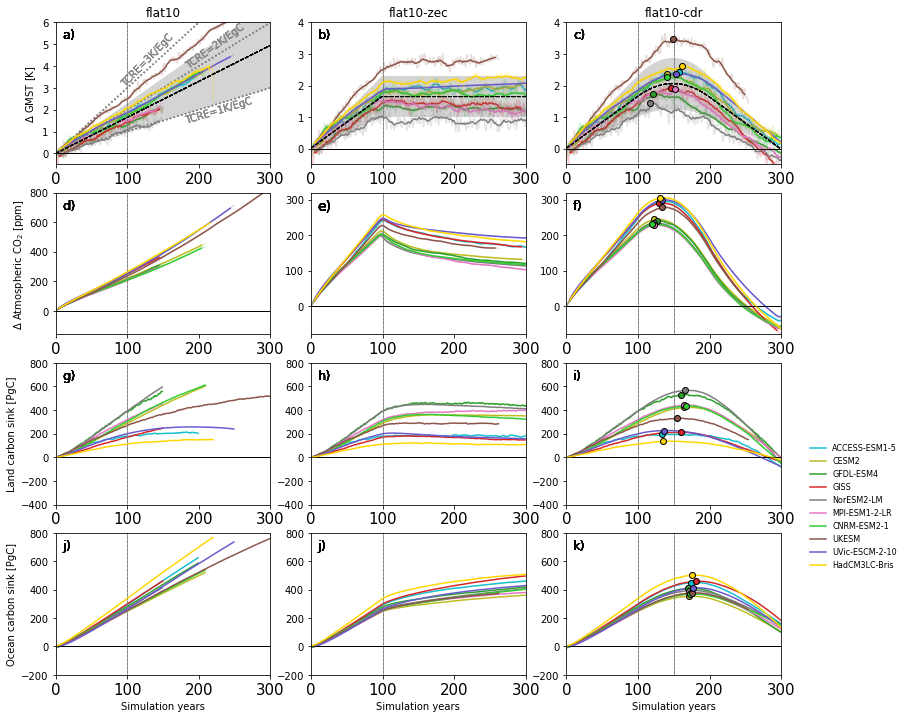

In [17]:
max_atmco2_list = []
max_landsink_list = []
max_oceansink_list = []
max_temp_list = []
max_totalsink_list = []
airborne_fraction_year100_list = []
land_sink_fraction_year100_list = []
ocean_sink_fraction_year100_list = []
PgC_per_ppm = 2.086


fig, axes = plt.subplots(4,3,figsize=(13, 12))
axes=axes.flatten()

### Temperature
for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10']['tas'])-int(window/2))

    axes[0].set_title("flat10")
    axes[0].set_ylabel("$\Delta$ GMST [K]")
    axes[0].set_ylim([-0.5,6])
    axes[0].set_xlim([0,300])
    axes[0].plot(ed[mdls[i]]['flat10']['tas'],alpha=0.2,color=colors[i])
    axes[0].plot(time_ma,moving_average(ed[mdls[i]]['flat10']['tas'],window),color=colors[i],label=mdls[i])

    axes[0].plot(np.arange(0,300)*10*1.65/1000, color='black', lw=1, linestyle="--")
    axes[0].fill_between(np.arange(0,320), np.arange(0,320)*10*1.0/1000, np.arange(0,320)*10*2.3/1000, color="gray", alpha=0.035, edgecolor="none")
    axes[0].plot([0,300],[0,3],':',color='grey',alpha=0.3)
    axes[0].plot([0,300],[0,6],':',color='grey',alpha=0.3)
    axes[0].plot([0,300],[0,9],':',color='grey',alpha=0.3)
    axes[0].text(60*3,.46*3,'TCRE=1K/EgC',rotation=17,color='grey',alpha=0.3)
    axes[0].text(30*3,1.02*3,'TCRE=3K/EgC',rotation=46,color='grey',alpha=0.3)
    axes[0].text(60*3,1.3*3,'TCRE=2K/EgC',rotation=36,color='grey',alpha=0.3)


    axes[0].axhline(0,lw=0.5,color="black")
    axes[0].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[0].annotate('a)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-zec']['tas'])-int(window/2))

    axes[1].set_title("flat10-zec")
    axes[1].set_ylim([-0.5,4])
    axes[1].set_xlim([0,300])
    axes[1].plot(ed[mdls[i]]['flat10-zec']['tas'],alpha=0.2,color=colors[i])
    axes[1].plot(time_ma,moving_average(ed[mdls[i]]['flat10-zec']['tas'],window),color=colors[i])

    axes[1].plot(np.cumsum(np.array(e_flat10_zec)[:,1])*1.65/1000, lw=1, color='black', linestyle="--")
    axes[1].fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_zec)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_zec)[:,1])*2.3/1000, lw=2, color="gray", alpha=0.035, edgecolor="none", zorder=2)

    axes[1].axhline(0,lw=0.5,color="black")
    axes[1].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[1].annotate('b)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-cdr']['tas'])-int(window/2))

    axes[2].set_title("flat10-cdr")
    axes[2].set_ylim([-0.5,4])
    axes[2].set_xlim([0,300])
    axes[2].plot(ed[mdls[i]]['flat10-cdr']['tas'],alpha=0.2,color=colors[i])
    axes[2].plot(time_ma,moving_average(ed[mdls[i]]['flat10-cdr']['tas'],window),color=colors[i])

    axes[2].plot(np.cumsum(np.array(e_flat10_cdr)[:,1])*1.65/1000, lw=1, color='black', linestyle="--")
    axes[2].fill_between(np.arange(0,320), np.cumsum(np.array(e_flat10_cdr)[:,1])*1.0/1000, np.cumsum(np.array(e_flat10_cdr)[:,1])*2.3/1000, lw=2, color="gray", alpha=0.035, edgecolor="none", zorder=2)

    # indicate max value
    mxy=np.max(moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['tas']),window))
    mxyidx = np.where(moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['tas']),window)==mxy)[0]
    axes[2].scatter(mxyidx,mxy,color=colors[i], edgecolor="black", zorder=4)

    max_temp_list.append([mxyidx[0], mxy])

    axes[2].axhline(0,lw=0.5,color="black")
    axes[2].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[2].axvline(150,lw=0.5,color="gray",linestyle=":")
    axes[2].annotate('c)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

### Atmospheric CO2
for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10']['co2'])-int(window/2))

    #axes[3].set_title("flat10")
    axes[3].set_ylabel("$\Delta$ Atmospheric CO$_2$ [ppm]")
    axes[3].set_ylim([-160,800])
    axes[3].set_xlim([0,300])
    axes[3].plot(ed[mdls[i]]['flat10']['co2']-ed[mdls[i]]['flat10']['co2'][0],alpha=0.2,color=colors[i])
    axes[3].plot(time_ma,moving_average(np.squeeze(ed[mdls[i]]['flat10']['co2']-ed[mdls[i]]['flat10']['co2'][0]),window),color=colors[i],label=mdls[i])

    axes[3].axhline(0,lw=0.5,color="black")
    axes[3].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[3].annotate('d)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-zec']['co2'])-int(window/2))

    #axes[4].set_title("flat10-zec")
    axes[4].set_ylim([-80,320])
    axes[4].set_xlim([0,300])
    axes[4].plot(ed[mdls[i]]['flat10-zec']['co2']-ed[mdls[i]]['flat10-zec']['co2'][0],alpha=0.2,color=colors[i])
    axes[4].plot(time_ma,moving_average(np.squeeze(ed[mdls[i]]['flat10-zec']['co2']-ed[mdls[i]]['flat10-zec']['co2'][0]),window),color=colors[i])

    axes[4].axhline(0,lw=0.5,color="black")
    axes[4].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[4].annotate('e)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=14, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-cdr']['co2'])-int(window/2))

    #axes[5].set_title("flat10-cdr")
    axes[5].set_ylim([-80,320])
    axes[5].set_xlim([0,300])
    axes[5].plot(ed[mdls[i]]['flat10-cdr']['co2']-ed[mdls[i]]['flat10-cdr']['co2'][0],alpha=0.2,color=colors[i])
    axes[5].plot(time_ma,moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['co2']-ed[mdls[i]]['flat10-cdr']['co2'][0]),window),color=colors[i])

    # indicate max value
    mxy=np.max(moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['co2']-ed[mdls[i]]['flat10-cdr']['co2'][0]),window))
    mxyidx = np.where(moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['co2']-ed[mdls[i]]['flat10-cdr']['co2'][0]),window)==mxy)[0]
    axes[5].scatter(mxyidx,mxy,color=colors[i], edgecolor="black", zorder=4)

    max_atmco2_list.append([mxyidx[0], mxy])

    airbornefrac = (ed[mdls[i]]['flat10-cdr']['C_atm'][100] - ed[mdls[i]]['flat10-cdr']['C_atm'][0])/(1000.)
    airborne_fraction_year100_list.append(np.squeeze(airbornefrac.data))
    
    axes[5].axhline(0,lw=0.5,color="black")
    axes[5].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[5].axvline(150,lw=0.5,color="gray",linestyle=":")
    axes[5].annotate('f)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

### Land carbon
for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10']['nbp'])-int(window/2))

    #axes[6].set_title("flat10")
    axes[6].set_ylabel("Land carbon sink [PgC]")
    axes[6].set_ylim([-400,800])
    axes[6].set_xlim([0,300])
    axes[6].plot(np.cumsum(ed[mdls[i]]['flat10']['nbp'].values),color=colors[i],label=mdls[i])
    axes[6].axhline(0,lw=0.5,color="black")
    axes[6].axvline(100,lw=0.5,color="gray",linestyle=":")
    #axes[6].legend(frameon=False, prop={'size': 8},ncol=2)
    axes[6].annotate('g)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-zec']['nbp'])-int(window/2))

    #axes[7].set_title("flat10-zec")
    axes[7].set_ylim([-400,800])
    axes[7].set_xlim([0,300])
    axes[7].plot(np.cumsum(ed[mdls[i]]['flat10-zec']['nbp']),color=colors[i])
    axes[7].axhline(0,lw=0.5,color="black")
    axes[7].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[7].annotate('h)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-cdr']['nbp'])-int(window/2))

    #axes[8].set_title("flat10-cdr")
    axes[8].set_ylim([-400,800])
    axes[8].set_xlim([0,300])
    axes[8].plot(np.cumsum(ed[mdls[i]]['flat10-cdr']['nbp']),color=colors[i])

    # indicate max value
    mxy=np.max(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['nbp'])),window))
    mxyidx = np.where(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['nbp'])),window)==mxy)[0]
    axes[8].scatter(mxyidx,mxy,color=colors[i], edgecolor="black", zorder=4)

    max_landsink_list.append([mxyidx[0], mxy])
    
    landsink_fraction = (np.cumsum(ed[mdls[i]]['flat10-cdr']['nbp'])[100])/1000.
    land_sink_fraction_year100_list.append(np.squeeze(landsink_fraction.data))

    axes[8].axhline(0,lw=0.5,color="black")
    axes[8].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[8].axvline(150,lw=0.5,color="gray",linestyle=":")
    axes[8].annotate('i)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

### Ocean carbon
for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10']['fgco2'])-int(window/2))

    #axes[9].set_title("flat10")
    axes[9].set_xlabel("Simulation years")
    axes[9].set_ylabel("Ocean carbon sink [PgC]")
    axes[9].set_ylim([-200,800])
    axes[9].set_xlim([0,300])
    axes[9].plot(np.cumsum(ed[mdls[i]]['flat10']['fgco2']),color=colors[i],label=mdls[i])
    axes[9].axhline(0,lw=0.5,color="black")
    axes[9].axvline(100,lw=0.5,color="gray",linestyle=":")
    #axes[9].legend(frameon=False, prop={'size': 8})
    axes[9].annotate('j)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-zec']['fgco2'])-int(window/2))

    #axes[10].set_title("flat10-zec")
    axes[10].set_xlabel("Simulation years")
    axes[10].set_ylim([-200,800])
    axes[10].set_xlim([0,300])
    axes[10].plot(np.cumsum(ed[mdls[i]]['flat10-zec']['fgco2']),color=colors[i])
    axes[10].axhline(0,lw=0.5,color="black")
    axes[10].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[10].annotate('j)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')

for i in np.arange(0,len(mdls)):
    #window =  11
    time_ma = np.arange(int(window/2),len(ed[mdls[i]]['flat10-cdr']['fgco2'])-int(window/2))

    #axes[11].set_title("flat10-cdr")
    axes[11].set_xlabel("Simulation years")
    axes[11].set_ylim([-200,800])
    axes[11].set_xlim([0,300])
    axes[11].plot(np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2']),color=colors[i],label=mdls[i])

    # indicate max value
    mxy=np.max(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'])),window))
    mxyidx = np.where(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'])),window)==mxy)[0]
    axes[11].scatter(mxyidx.data,mxy,color=colors[i], edgecolor="black", zorder=4)
    
    max_oceansink_list.append([mxyidx[0], mxy])
    
    oceansink_fraction = (np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'])[100] - np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'])[0] )/1000.
    ocean_sink_fraction_year100_list.append(np.squeeze(oceansink_fraction.data))
  
    mxy=np.max(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'] + ed[mdls[i]]['flat10-cdr']['nbp']  )),window))
    mxyidx = np.where(moving_average(np.squeeze(np.cumsum(ed[mdls[i]]['flat10-cdr']['fgco2'] + ed[mdls[i]]['flat10-cdr']['nbp']  )),window)==mxy)[0]
    max_totalsink_list.append([mxyidx[0], mxy])

    axes[11].axhline(0,lw=0.5,color="black")
    axes[11].axvline(100,lw=0.5,color="gray",linestyle=":")
    axes[11].axvline(150,lw=0.5,color="gray",linestyle=":")
    axes[11].annotate('k)', xy=(0.03, 0.91), xycoords='axes fraction', fontsize=13, ha='left', va='center')
    axes[11].legend(frameon=False, prop={'size': 8}, bbox_to_anchor=(1.1, 0.69))
fig.subplots_adjust(wspace=0.19, hspace=0.2)

plt.savefig("images/flat10_ESM_results_panel.pdf")
plt.savefig("images/flat10_ESM_results_panel.jpg")

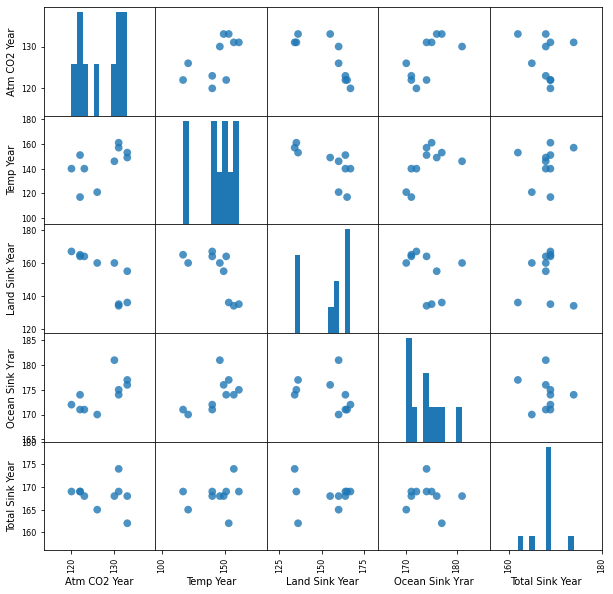

In [18]:
peak_years = pd.DataFrame((np.array(max_atmco2_list)[:,0], np.array(max_temp_list)[:,0], np.array(max_landsink_list)[:,0], np.array(max_oceansink_list)[:,0], np.array(max_totalsink_list)[:,0])).transpose()

peak_years.columns = ['Atm CO2 Year','Temp Year','Land Sink Year','Ocean Sink Yrar','Total Sink Year']
peak_years.index = mdls
peak_years

g = pd.plotting.scatter_matrix(peak_years, figsize=(10,10), marker = 'o', hist_kwds = {'bins': 10}, s = 60, alpha = 0.8, range_padding=1)

plt.show()

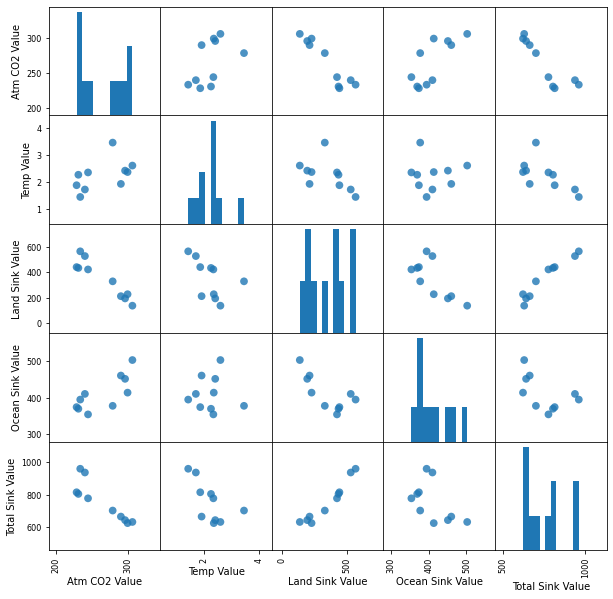

In [19]:
peak_amounts = pd.DataFrame((np.array(max_atmco2_list)[:,1], np.array(max_temp_list)[:,1], np.array(max_landsink_list)[:,1], np.array(max_oceansink_list)[:,1], np.array(max_totalsink_list)[:,1])).transpose()

peak_amounts.columns = ['Atm CO2 Value','Temp Value','Land Sink Value','Ocean Sink Value','Total Sink Value']
peak_amounts.index = mdls
peak_amounts

g = pd.plotting.scatter_matrix(peak_amounts, figsize=(10,10), marker = 'o', hist_kwds = {'bins': 10}, s = 60, alpha = 0.8, range_padding=1)

plt.show()

In [20]:
peak_amounts.to_csv('peak_amounts.csv')
peak_years.to_csv('peak_years.csv')

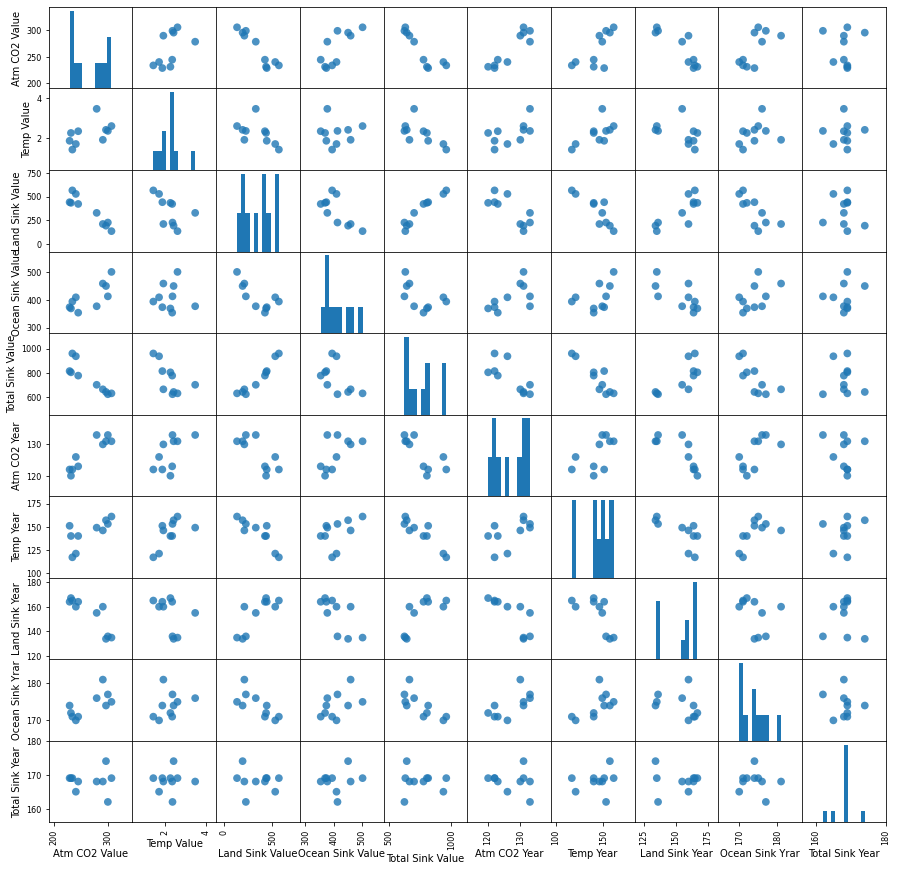

In [21]:
all_peak_data = pd.concat((peak_amounts, peak_years), axis=1)

g = pd.plotting.scatter_matrix(all_peak_data, figsize=(15,15), marker = 'o', hist_kwds = {'bins': 10}, s = 60, alpha = 0.8, range_padding=1)

plt.show()

In [22]:




sink_fractions = pd.DataFrame((np.array(airborne_fraction_year100_list), np.array(land_sink_fraction_year100_list), np.array(ocean_sink_fraction_year100_list))).transpose()
sink_fractions.columns = ['flat10 airborne frac','flat10 land frac','flat10 ocean frac']
sink_fractions.index = mdls

print(sink_fractions)
print()
print(sink_fractions.sum(axis=1))
sink_fractions.to_csv('sink_fractions.csv')

                flat10 airborne frac  flat10 land frac  flat10 ocean frac
ACCESS-ESM1-5               0.527063          0.179362           0.293310
CESM2                       0.466450          0.288553           0.246965
GFDL-ESM4                   0.446569          0.391603           0.288937
GISS                        0.534603          0.170269           0.299909
NorESM2-LM                  0.448658          0.391468           0.268877
MPI-ESM1-2-LR               0.438080          0.318949           0.250147
CNRM-ESM2-1                 0.442461          0.304928           0.253560
UKESM                       0.500502          0.269030           0.253596
UVic-ESCM-2-10              0.540086          0.199707           0.264177
HadCM3LC-Bris               0.561165          0.112762           0.338200

ACCESS-ESM1-5     0.999735
CESM2             1.001968
GFDL-ESM4         1.127109
GISS              1.004781
NorESM2-LM        1.109003
MPI-ESM1-2-LR     1.007176
CNRM-ESM2-1       1.000

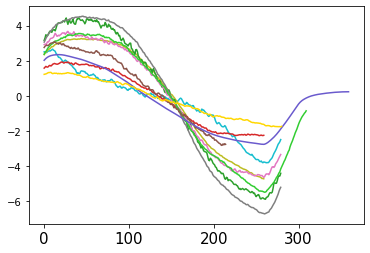

In [23]:
for i in np.arange(0,len(mdls)):
    plt.plot(moving_average(np.squeeze(ed[mdls[i]]['flat10-cdr']['nbp']),41),color=colors[i],label=mdls[i])

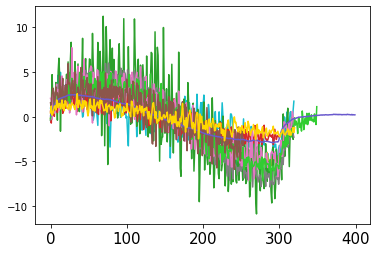

In [24]:
for i in np.arange(0,len(mdls)):
    plt.plot(np.squeeze(ed[mdls[i]]['flat10-cdr']['nbp']),color=colors[i],label=mdls[i])

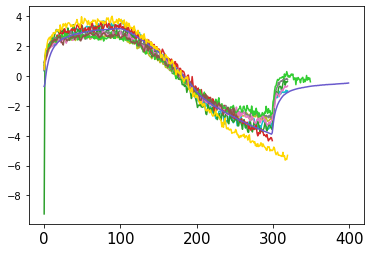

In [25]:
for i in np.arange(0,len(mdls)):
    plt.plot(np.squeeze(ed[mdls[i]]['flat10-cdr']['fgco2'][:]),color=colors[i],label=mdls[i])

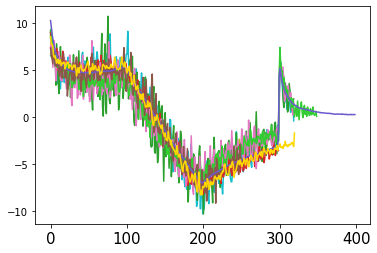

In [26]:
for i in np.arange(0,len(mdls)):
    plt.plot(PgC_per_ppm * np.diff(np.squeeze(ed[mdls[i]]['flat10-cdr']['co2'])),color=colors[i],label=mdls[i])

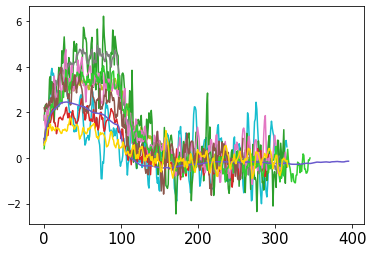

In [27]:
for i in np.arange(0,len(mdls)):
    plt.plot(moving_average(np.squeeze(ed[mdls[i]]['flat10-zec']['nbp']), 5),color=colors[i],label=mdls[i])

In [28]:
def memory(emissions, tau, sens):
    nt = len(emissions)
    sink = np.zeros(nt)
    for t in range(nt):
        r = 0
        for tt in range(t):
            r = r + emissions[tt] * sens * np.exp(-(t-tt)/tau)
        sink[t] = r
    return sink

def memory_xr(emissions, tau, sens):
    nt = len(emissions)
    sink = 0.*emissions['time']*tau
    for t in range(nt):
        r = 0
        for tt in range(t):
            r = r + emissions[tt] * sens * np.exp(-(t-tt)/tau)
        sink.loc[dict(time=t)] = r
    return sink

def memory_2timescale(emissions, tau1, tau2, sens1, sens2):
    nt = len(emissions)
    sink = np.zeros(nt)
    for t in range(nt):
        r = 0
        for tt in range(t):
            r = r + emissions[tt] * (sens1 * np.exp(-(t-tt)/tau1) + sens2 * np.exp(-(t-tt)/tau2))
        sink[t] = r
    return sink
    

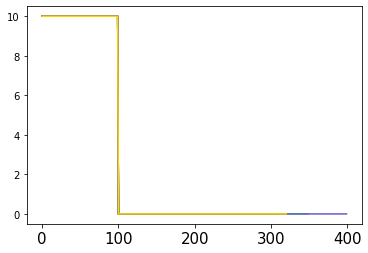

In [29]:
for i in np.arange(0,len(mdls)):
    plt.plot(np.squeeze(ed[mdls[i]]['flat10-zec']['fco2fos']),color=colors[i],label=mdls[i])

[0.57285996 0.84687917]
[18.35878927  0.01926295]
[13.63212367  0.03335441]
[5.12844555 0.03801745]
[12.62275374  0.03630026]
[12.3352619   0.02971646]
[15.45804252  0.02379904]
[4.37426154 0.07099246]
[3.67296651 0.06438839]
[3.19028643 0.0417874 ]


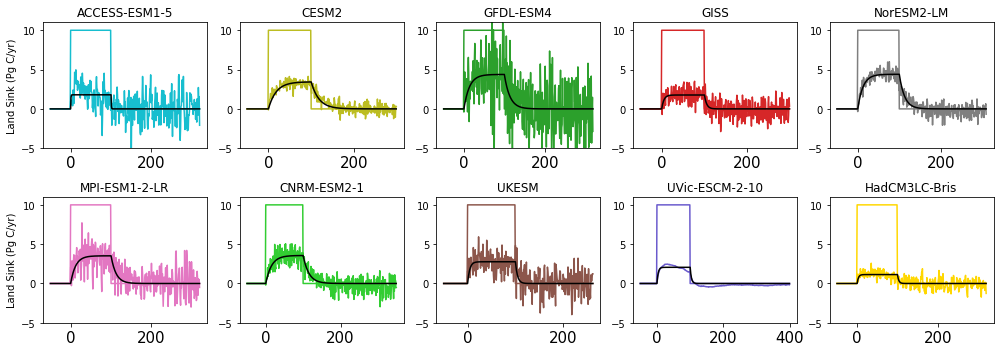

In [48]:
fig = plt.figure(figsize=(14,5))

years_to_pad_front = 50

land_sink_curvefit_params_list = []
for i in np.arange(0,len(mdls)):
    # subfigure 1
    sub = fig.add_subplot(2, 5, i+1)

    ntim_orig = len(np.squeeze(ed[mdls[i]]['flat10-zec']['fco2fos']))
    ntim = ntim_orig + years_to_pad_front
    year = np.arange(ntim)-years_to_pad_front
    emiss_flat10_zec = np.zeros(ntim)
    landsink_flat10_zec = np.zeros(ntim)
    emiss_flat10_zec[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-zec']['fco2fos'])
    landsink_flat10_zec[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-zec']['nbp'])
    #
    params, fit = scipy.optimize.curve_fit(memory, emiss_flat10_zec, landsink_flat10_zec, [12., 0.03])
    print(params)
    land_sink_curvefit_params_list.append(params)
    pred_landsink = memory(emiss_flat10_zec, params[0], params[1])
    #
    #
    #try:
    #    params_combined_2timescale, fit_combined_2timescale = scipy.optimize.curve_fit(memory_2timescale, emiss_flat10_zec, landsink_flat10_zec, [5., 20., 0.02, 0.001])
    #    print(params_combined_2timescale)
    #    pred_totalsink_2timescale = memory_2timescale(emiss_flat10_zec, params_combined_2timescale[0], params_combined_2timescale[1], params_combined_2timescale[2], params_combined_2timescale[3])
    #    succeeded = True
    #except:
    #    succeeded = False
    #
    sub.plot(year, emiss_flat10_zec,color=colors[i])
    sub.plot(year, landsink_flat10_zec,color=colors[i])
    sub.plot(year, pred_landsink,color='black')
    sub.title.set_text(mdls[i])
    if i%5 == 0:
        sub.set_ylabel('Land Sink (Pg C/yr)')
    #if succeeded:
    #    sub.plot(pred_totalsink_2timescale,color='blue',label=mdls[i])
    sub.set_ylim(-5,11)

plt.tight_layout()
plt.show()

[2.85749012e+01 1.32131080e-02]
[2.79267998e+00 1.22611937e+02 8.75400515e-02 2.41097402e-03]
[11.64291122  0.02424393]
[2.97339229e+00 2.05877955e+02 8.23852738e-02 1.05039192e-03]
[11.8676698   0.02788676]
[3.62430491e+00 2.54848476e+02 7.81434890e-02 1.11012176e-03]
[3.13929173e+01 1.24704429e-02]
[3.46249120e+00 1.81303846e+02 7.38892297e-02 2.00542726e-03]
[9.50864929 0.03175128]
[1.82614321e+00 3.54852270e+02 1.63070675e-01 1.00623699e-03]
[1.96767456e+01 1.52850454e-02]
[3.71726637e+00 1.58637107e+02 6.03352306e-02 1.45668044e-03]
[11.87518477  0.02432502]
[2.29420843e+00 4.21078493e+02 1.14733782e-01 9.99304890e-04]
[1.77767182e+01 1.67913340e-02]
[2.68019482e+00 1.64053245e+02 8.87335720e-02 1.46028759e-03]
[3.26020134e+01 1.10056162e-02]
[7.60127291e+00 1.79334370e+02 2.93916872e-02 1.65951781e-03]
[19.1516213   0.02110164]
[2.69617098e+00 1.28494815e+02 1.13593736e-01 2.27616481e-03]


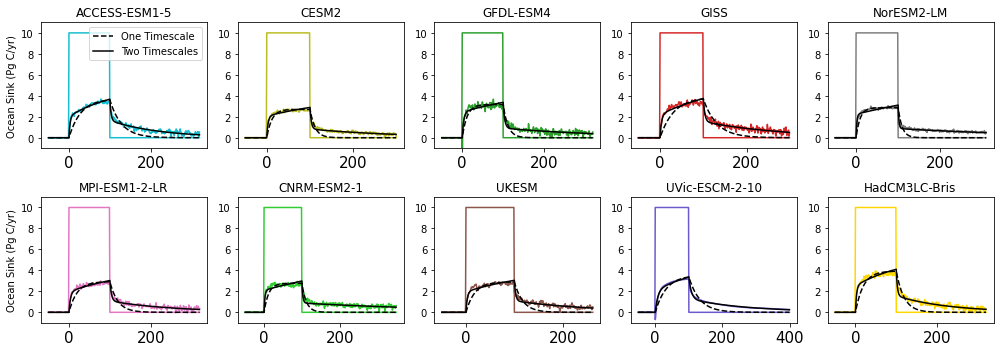

In [58]:
fig = plt.figure(figsize=(14,5))

years_to_pad_front = 50

ocean_sink_curvefit_single_params_list = []
ocean_sink_curvefit_double_params_list = []

for i in np.arange(0,len(mdls)):
    # subfigure 1
    sub = fig.add_subplot(2, 5, i+1)

    ntim_orig = len(np.squeeze(ed[mdls[i]]['flat10-zec']['fco2fos']))
    ntim = ntim_orig + years_to_pad_front
    year = np.arange(ntim)-years_to_pad_front
    emiss_flat10_zec = np.zeros(ntim)
    oceansink_flat10_zec = np.zeros(ntim)
    emiss_flat10_zec[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-zec']['fco2fos'])
    oceansink_flat10_zec[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-zec']['fgco2'])
    #
    params, fit = scipy.optimize.curve_fit(memory, emiss_flat10_zec, np.nan_to_num(oceansink_flat10_zec), [12., 0.03])
    print(params)
    ocean_sink_curvefit_single_params_list.append(params)
    pred_oceansink = memory(emiss_flat10_zec, params[0], params[1])
    #
    #
    try:
        params_combined_2timescale, fit_combined_2timescale = scipy.optimize.curve_fit(memory_2timescale, emiss_flat10_zec, np.nan_to_num(oceansink_flat10_zec), [5., 20., 0.02, 0.001])
        print(params_combined_2timescale)
        pred_totalsink_2timescale = memory_2timescale(emiss_flat10_zec, params_combined_2timescale[0], params_combined_2timescale[1], params_combined_2timescale[2], params_combined_2timescale[3])
        ocean_sink_curvefit_double_params_list.append(params_combined_2timescale)
        succeeded = True
    except:
        succeeded = False
        ocean_sink_curvefit_double_params_list.append(np.nan)
    #
    sub.plot(year, emiss_flat10_zec,color=colors[i])
    sub.plot(year, oceansink_flat10_zec,color=colors[i])
    sub.plot(year, pred_oceansink,color='black', linestyle='--', label='One Timescale')
    sub.title.set_text(mdls[i])
    if succeeded:
        sub.plot(year, pred_totalsink_2timescale,color='black', label='Two Timescales')
    if i%5 == 0:
        sub.set_ylabel('Ocean Sink (Pg C/yr)')
    if i == 0:
        sub.legend()
    sub.set_ylim(-1,11)
    
plt.tight_layout()
plt.show()

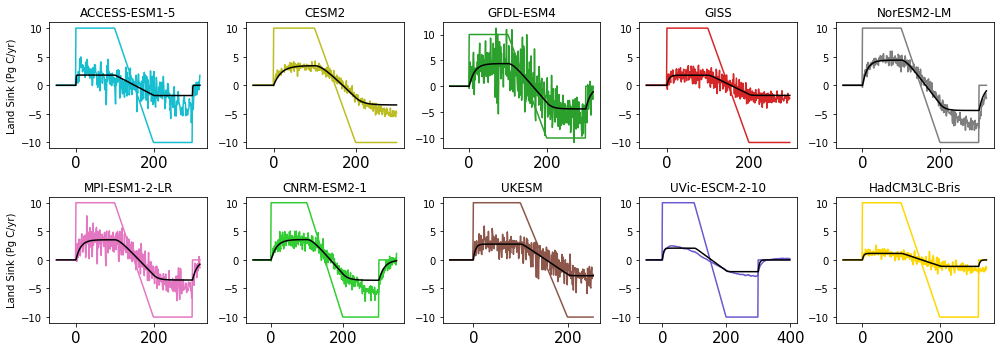

In [50]:
fig = plt.figure(figsize=(14,5))

years_to_pad_front = 50

for i in np.arange(0,len(mdls)):
    # subfigure 1
    sub = fig.add_subplot(2, 5, i+1)

    ntim_orig = len(np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos']))
    ntim = ntim_orig + years_to_pad_front
    year = np.arange(ntim)-years_to_pad_front
    emiss_flat10_cdr = np.zeros(ntim)
    landsink_flat10_cdr = np.zeros(ntim)
    emiss_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos'])
    landsink_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['nbp'])
    #
    pred_landsink = memory(emiss_flat10_cdr, land_sink_curvefit_params_list[i][0], land_sink_curvefit_params_list[i][1])
    #
    #
    #try:
    #    params_combined_2timescale, fit_combined_2timescale = scipy.optimize.curve_fit(memory_2timescale, emiss_flat10_zec, landsink_flat10_zec, [5., 20., 0.02, 0.001])
    #    print(params_combined_2timescale)
    #    pred_totalsink_2timescale = memory_2timescale(emiss_flat10_zec, params_combined_2timescale[0], params_combined_2timescale[1], params_combined_2timescale[2], params_combined_2timescale[3])
    #    succeeded = True
    #except:
    #    succeeded = False
    #
    sub.plot(year, emiss_flat10_cdr,color=colors[i])
    sub.plot(year, landsink_flat10_cdr,color=colors[i])
    sub.plot(year, pred_landsink,color='black')
    sub.title.set_text(mdls[i])
    if i%5 == 0:
        sub.set_ylabel('Land Sink (Pg C/yr)')
    #if succeeded:
    #    sub.plot(pred_totalsink_2timescale,color='blue',label=mdls[i])

plt.tight_layout()
plt.show()

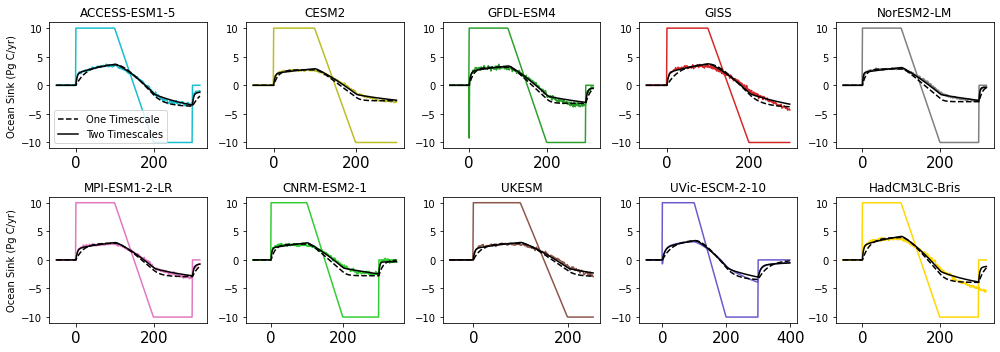

In [59]:
fig = plt.figure(figsize=(14,5))

years_to_pad_front = 50

for i in np.arange(0,len(mdls)):
    # subfigure 1
    sub = fig.add_subplot(2, 5, i+1)

    ntim_orig = len(np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos']))
    ntim = ntim_orig + years_to_pad_front
    year = np.arange(ntim)-years_to_pad_front
    emiss_flat10_cdr = np.zeros(ntim)
    oceansink_flat10_cdr = np.zeros(ntim)
    emiss_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos'])
    oceansink_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['fgco2'])
    #
    pred_oceansink = memory(emiss_flat10_cdr, ocean_sink_curvefit_single_params_list[i][0], ocean_sink_curvefit_single_params_list[i][1])
    #
    pred_totalsink_2timescale = memory_2timescale(emiss_flat10_cdr, ocean_sink_curvefit_double_params_list[i][0], ocean_sink_curvefit_double_params_list[i][1], ocean_sink_curvefit_double_params_list[i][2], ocean_sink_curvefit_double_params_list[i][3])
    #
    sub.plot(year, emiss_flat10_cdr,color=colors[i])
    sub.plot(year, oceansink_flat10_cdr,color=colors[i])
    sub.plot(year, pred_oceansink,color='black', linestyle='--', label='One Timescale')
    sub.title.set_text(mdls[i])
    sub.plot(year, pred_totalsink_2timescale,color='black', label='Two Timescales')
    if i%5 == 0:
        sub.set_ylabel('Ocean Sink (Pg C/yr)')
    if i == 0:
        sub.legend()
plt.tight_layout()
plt.show()

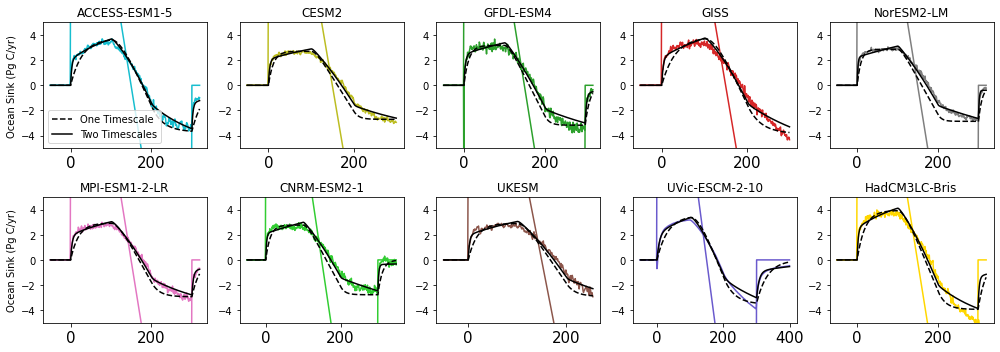

In [61]:
fig = plt.figure(figsize=(14,5))

years_to_pad_front = 50

for i in np.arange(0,len(mdls)):
    # subfigure 1
    sub = fig.add_subplot(2, 5, i+1)

    ntim_orig = len(np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos']))
    ntim = ntim_orig + years_to_pad_front
    year = np.arange(ntim)-years_to_pad_front
    emiss_flat10_cdr = np.zeros(ntim)
    oceansink_flat10_cdr = np.zeros(ntim)
    emiss_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['fco2fos'])
    oceansink_flat10_cdr[years_to_pad_front:] = np.squeeze(ed[mdls[i]]['flat10-cdr']['fgco2'])
    #
    pred_oceansink = memory(emiss_flat10_cdr, ocean_sink_curvefit_single_params_list[i][0], ocean_sink_curvefit_single_params_list[i][1])
    #
    pred_totalsink_2timescale = memory_2timescale(emiss_flat10_cdr, ocean_sink_curvefit_double_params_list[i][0], ocean_sink_curvefit_double_params_list[i][1], ocean_sink_curvefit_double_params_list[i][2], ocean_sink_curvefit_double_params_list[i][3])
    #
    sub.plot(year, emiss_flat10_cdr,color=colors[i])
    sub.plot(year, oceansink_flat10_cdr,color=colors[i])
    sub.plot(year, pred_oceansink,color='black', linestyle='--', label='One Timescale')
    sub.title.set_text(mdls[i])
    sub.plot(year, pred_totalsink_2timescale,color='black', label='Two Timescales')
    if i%5 == 0:
        sub.set_ylabel('Ocean Sink (Pg C/yr)')
    if i == 0:
        sub.legend()
    sub.set_ylim(-5,5)
plt.tight_layout()
plt.show()

In [53]:
land_sink_expfit = pd.DataFrame((np.array(land_sink_curvefit_params_list)[:,0], np.array(land_sink_curvefit_params_list)[:,1])).transpose()

land_sink_expfit.columns = ['Land Sink Lag','Land Sink Scaling']
land_sink_expfit.index = mdls
land_sink_expfit


,Land Sink Lag,Land Sink Scaling
ACCESS-ESM1-5,0.572860,0.846879
CESM2,18.358789,0.019263
GFDL-ESM4,13.632124,0.033354
GISS,5.128446,0.038017
NorESM2-LM,12.622754,0.036300
MPI-ESM1-2-LR,12.335262,0.029716
CNRM-ESM2-1,15.458043,0.023799
UKESM,4.374262,0.070992
UVic-ESCM-2-10,3.672967,0.064388
HadCM3LC-Bris,3.190286,0.041787


In [56]:
ocean_sink_singleexpfit = pd.DataFrame((np.array(ocean_sink_curvefit_single_params_list)[:,0], np.array(ocean_sink_curvefit_single_params_list)[:,1])).transpose()

ocean_sink_singleexpfit.columns = ['Ocean Sink Lag','Ocean Sink Scaling']
ocean_sink_singleexpfit.index = mdls
ocean_sink_singleexpfit


,Ocean Sink Lag,Ocean Sink Scaling
ACCESS-ESM1-5,28.574901,0.013213
CESM2,11.642911,0.024244
GFDL-ESM4,11.867670,0.027887
GISS,31.392917,0.012470
NorESM2-LM,9.508649,0.031751
MPI-ESM1-2-LR,19.676746,0.015285
CNRM-ESM2-1,11.875185,0.024325
UKESM,17.776718,0.016791
UVic-ESCM-2-10,32.602013,0.011006
HadCM3LC-Bris,19.151621,0.021102


In [36]:
ocean_sink_doubleexpfit = pd.DataFrame((np.array(ocean_sink_curvefit_double_params_list)[:,0], np.array(ocean_sink_curvefit_double_params_list)[:,1], np.array(ocean_sink_curvefit_double_params_list)[:,2], np.array(ocean_sink_curvefit_double_params_list)[:,3])).transpose()

ocean_sink_doubleexpfit.columns = ['Ocean Sink Lag 1','Ocean Sink Lag 2','Ocean Sink Scaling 1','Ocean Sink Scaling 2']
ocean_sink_doubleexpfit.index = mdls
ocean_sink_doubleexpfit


,Ocean Sink Lag 1,Ocean Sink Lag 2,Ocean Sink Scaling 1,Ocean Sink Scaling 2
ACCESS-ESM1-5,2.792680,122.611937,0.087540,0.002411
CESM2,2.973392,205.877955,0.082385,0.001050
GFDL-ESM4,3.624305,254.848476,0.078143,0.001110
GISS,3.462491,181.303846,0.073889,0.002005
NorESM2-LM,1.826143,354.852270,0.163071,0.001006
MPI-ESM1-2-LR,3.717266,158.637107,0.060335,0.001457
CNRM-ESM2-1,2.294208,421.078493,0.114734,0.000999
UKESM,2.680195,164.053245,0.088734,0.001460
UVic-ESCM-2-10,7.601273,179.334370,0.029392,0.001660
HadCM3LC-Bris,2.696171,128.494815,0.113594,0.002276


In [37]:
land_sink_expfit.to_csv('land_sink_expfit.csv')
ocean_sink_singleexpfit.to_csv('ocean_sink_singleexpfit.csv')
ocean_sink_doubleexpfit.to_csv('ocean_sink_doubleexpfit.csv')
